# Attention UNet -- both phases, 5-fold cross-validation

K-fold sibling of `context_slices_kfold_diagnostics.ipynb`,
`both_phase_loss_ablation_kfold_diagnostics.ipynb` and
`both_phase_augmentation_kfold_diagnostics.ipynb`. Fixes the configuration
those notebooks converged on -- `phase='both'`, `augment=True`,
`loss='dice_ce'`, `context_slices=0` -- and varies the **architecture**
instead.

**Two attention arms, and the difference between them is the whole point.**

- **`attn_gates`** (`--arch unet_attn_gates`, `unet/attention_gate_unet.py`) --
  the milesial UNet with MONAI's `AttentionBlock` (Oktay et al. 2018) gating
  each skip connection before the existing `torch.cat`, and **nothing else
  changed**: same `DoubleConv`/`Down`/`OutConv`, same 64/128/256/512/1024
  widths, same maxpool downsampling, same `bilinear` handling, same `Up`
  padding rule. Verified structurally in the "Architectures" cell below --
  every `UNet` parameter name and shape survives, the gates add 84 tensors
  (+352k params, +1.13%). This is the **clean single-variable ablation**: a
  difference against the baseline is attributable to the gates alone.
- **`attn_unet`** (`--arch attention_unet`, `unet/attention_unet.py`) --
  MONAI's whole `AttentionUnet` network. Also attention-gated, but it
  *additionally* swaps maxpool for stride-2 convs, always upsamples with
  transposed convs, and fuses gated skip + decoder feature with a conv
  instead of concatenating into a `DoubleConv`. A difference here is "this
  architecture vs that architecture", **not** evidence about attention.

Both were trained; keeping both is what makes the result interpretable (see
**Interpretation** at the bottom). Historically `attn_unet` was trained first
by mistake -- the intended arm was always the gate-only ablation -- but having
both turned an ambiguous result into a clean attribution, so both are kept and
reported.

**The baseline arm reuses already-finished checkpoints, no retraining.**
`both_data_aug_dice_ce_kfold{0..4}` (from
`both_phase_augmentation_kfold_diagnostics.ipynb` / `run_both_phase_kfold.sh`)
are already `phase='both'`, `augment=True`, `loss='dice_ce'`,
`context_slices=0`, `split_seed=0`, `seed=fold`, 40 epochs, batch 8,
`img_scale=0.5`, poly LR, `select_on=macro_dice` -- exactly the config both
attention arms match apart from `--arch`, confirmed against their
`run_config.json` files. `run_name_for()` below special-cases the baseline to
point at those existing run directories.

**Learning rate was NOT re-tuned per architecture.** Every arm trains at
train.py's 1e-5 default, the value every run in this project has used. That is
the right call for an architecture comparison -- re-tuning only one arm would
confound it -- but it bounds the conclusion: a negative or null result means
"no benefit at this project's training configuration", not "attention cannot
help". The **Convergence check** section below tests the premise that 1e-5 for
40 epochs was adequate for each arm rather than assuming it.

**Training does not happen in this kernel.** From a terminal:
`bash run_attn_gates_kfold.sh` and `bash run_attention_kfold.sh` (pass GPU
indices to pin them; a single index forces strictly sequential folds). This
notebook confirms the split, then reads results back from disk -- same
resume-from-disk design as its siblings. Measured wall-clock on one shared
GPU: ~4.6 h for the five `attn_gates` folds, ~12.5 h for the five `attn_unet`
folds.

**Scale:** `IMG_SCALE = 0.5`, matching what every checkpoint here was actually
trained at (`run_config.json`). See `context_slices_kfold_diagnostics.ipynb`'s
intro for why this matters -- scoring these models at scale 1.0 does not
degrade them mildly, it breaks them (macro Dice 0.9053 -> 0.5230).

## Setup

In [1]:
import os

# only needed for the Architectures cell (CPU-only) and the final test-set
# scoring cell at the bottom -- every pooled-analysis cell reads CSVs from disk
# and never touches the GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "9"
print(f"Targeting GPU: {os.environ['CUDA_VISIBLE_DEVICES']}")

Targeting GPU: 9


In [2]:
import sys
sys.path.append('.')

import json
import logging
import numpy as np
import torch
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

/hpc/jgeo610/Virtual_ENV/unet_env/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Using device: cuda
Tesla V100-PCIE-32GB


In [3]:
import train
from utils import metrics
from utils.data_loading import VolumeMRIDataset

train.dir_img = Path('./data/imgs/')
train.dir_mask = Path('./data/masks/')
train.dir_checkpoint = Path('./checkpoints/')

## Experiment configuration

In [4]:
PHASE      = 'both'
LOSS       = 'dice_ce'
AUGMENT    = True
K_FOLDS    = 5

ARMS = ['unet', 'attn_gates', 'attn_unet']
BASELINE_ARM = 'unet'
# --arch value passed to train.py for each arm; also what lands in run_config.json
ARCH_FOR = {'unet': 'unet', 'attn_gates': 'unet_attn_gates', 'attn_unet': 'attention_unet'}

SPLIT_SEED   = 0        # FROZEN. Identical to every other both_* notebook -- do not
                        # change; this is what keeps the test set identical across all of them.
EPOCHS       = 40
BATCH_SIZE   = 8
LR           = 1e-5     # NOT re-tuned per architecture -- see the intro cell
IMG_SCALE    = 0.5      # what these checkpoints actually trained at (run_config.json)
N_CLASSES    = train.PHASE_N_CLASSES[PHASE]     # 6 for 'both' (bg + LV/RV/LA/RA/EAT)
N_CHANNELS   = train.n_channels_for(PHASE, 0)   # 2 for 'both', context_slices=0
AMP          = True
SELECT_ON    = 'macro_dice'
LR_SCHEDULE  = 'poly'
TEST_PERCENT = 0.15


def run_name_for(arm, fold):
    if arm == BASELINE_ARM:
        # reuse both_phase_augmentation_kfold_diagnostics.ipynb's already-finished
        # runs -- see the intro cell. These ARE the control, not an approximation.
        return f'data_aug_{LOSS}_kfold{fold}'
    if arm == 'attn_gates':
        return f'attngate_kfold{fold}'
    return f'attn_kfold{fold}'


RUN_NAME_FN = {arm: (lambda f, arm=arm: run_name_for(arm, f)) for arm in ARMS}

# train_model prefixes non-water run names with '{phase}_' internally -- see
# CLAUDE.md. Mirrors run_dir_for() in every other both_* notebook.
def run_dir_for(run_name):
    full_name = run_name if PHASE == 'water' else f'{PHASE}_{run_name}'
    return train.dir_checkpoint / full_name


# same validated CVD-safe palette the sibling notebooks use -- baseline always
# blue, the clean gate ablation orange, MONAI's whole network green
ARM_COLORS = {'unet': '#2a78d6', 'attn_gates': '#eb6834', 'attn_unet': '#1baf7a'}
assert BASELINE_ARM in ARMS

print(f'{K_FOLDS}-fold, {EPOCHS} epochs each, {len(ARMS)} arms:')
for arm in ARMS:
    for f in range(K_FOLDS):
        d = run_dir_for(run_name_for(arm, f))
        done = (d / 'run_config.json').exists() and 'finished' in json.loads(
            (d / 'run_config.json').read_text())
        print(f'  {d.name:<34} (--arch {ARCH_FOR[arm]:<16})'
              + ('  [finished]' if done else '  [MISSING]'))

POOLED_DIR = train.dir_checkpoint / f'{PHASE}_attention_kfold_pooled'
PLOTS_DIR = POOLED_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'\npooled outputs -> {POOLED_DIR}')

5-fold, 40 epochs each, 3 arms:
  both_data_aug_dice_ce_kfold0       (--arch unet            )  [finished]
  both_data_aug_dice_ce_kfold1       (--arch unet            )  [finished]
  both_data_aug_dice_ce_kfold2       (--arch unet            )  [finished]
  both_data_aug_dice_ce_kfold3       (--arch unet            )  [finished]
  both_data_aug_dice_ce_kfold4       (--arch unet            )  [finished]
  both_attngate_kfold0               (--arch unet_attn_gates )  [finished]
  both_attngate_kfold1               (--arch unet_attn_gates )  [finished]
  both_attngate_kfold2               (--arch unet_attn_gates )  [finished]
  both_attngate_kfold3               (--arch unet_attn_gates )  [finished]
  both_attngate_kfold4               (--arch unet_attn_gates )  [finished]
  both_attn_kfold0                   (--arch attention_unet  )  [finished]
  both_attn_kfold1                   (--arch attention_unet  )  [finished]
  both_attn_kfold2                   (--arch attention_unet  )  [fin

## Dataset

In [5]:
dataset = VolumeMRIDataset(train.dir_img, train.dir_mask, scale=IMG_SCALE,
                           phase=PHASE, context_slices=0)

print(f'{len(dataset.mask_file_for)} patients, {len(dataset.index)} slices')
print(f'mask values: {dataset.mask_values}')
print(f'sample image shape {tuple(dataset[0]["image"].shape)}  (expect {N_CHANNELS} channels)')

INFO: Found 50 patients, 4748 total slices


INFO: Scanning mask files to determine unique values...


INFO: Unique mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


50 patients, 4748 slices
mask values: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]


sample image shape (2, 216, 216)  (expect 2 channels)


### Confirm the folds and the test set before trusting any comparison

Same assertion block as the sibling notebooks. Both attention arms were
trained at `split_seed=0`, so they pair patient-for-patient against the
baseline; if this cell ever fails, the pooled comparison below is invalid.

In [6]:
EXPECTED_TEST_PATIENTS = ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532',
                          'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']

all_val_patients = []
test_patients = None
for f in range(K_FOLDS):
    train_idx, val_idx, test_idx = train.split_patients_kfold(
        dataset, fold=f, k_folds=K_FOLDS, test_percent=TEST_PERCENT, seed=SPLIT_SEED
    )
    fold_test = sorted({dataset.index[i][0] for i in test_idx})
    fold_val = sorted({dataset.index[i][0] for i in val_idx})
    fold_train = sorted({dataset.index[i][0] for i in train_idx})

    if test_patients is None:
        test_patients = fold_test
    assert fold_test == test_patients, f'fold {f} has a different test set!'
    assert not (set(fold_val) & set(fold_train)), f'fold {f}: train/val overlap'
    assert not (set(fold_val) & set(fold_test)), f'fold {f}: val/test overlap'

    all_val_patients.append(set(fold_val))
    print(f'fold {f}: train {len(fold_train):>2} / val {len(fold_val):>2}   val = {fold_val}')

assert test_patients == EXPECTED_TEST_PATIENTS, \
    f'test set does not match the frozen split! got {test_patients}'

pool = set(dataset.mask_file_for) - set(test_patients)
union = set().union(*all_val_patients)
assert union == pool, 'folds do not cover the whole train+val pool'
for i in range(K_FOLDS):
    for j in range(i + 1, K_FOLDS):
        assert not (all_val_patients[i] & all_val_patients[j]), f'folds {i} and {j} overlap'

print(f'\nOK: test set matches the frozen split ({len(test_patients)} patients), '
      f'{K_FOLDS} folds are disjoint and cover the {len(pool)}-patient pool')

INFO: Patient-level 5-fold split of 50 patients / 4748 slices (seed 0), fold 0/4:
        train: 33 patients,  3138 slices
        val:    9 patients,   836 slices  ['CADRE_1382_second', 'CADRE_1395_second', 'CADRE_1521', 'CADRE_1671', 'CADRE_1855', 'CADRE_1857', 'CADRE_1861', 'CADRE_1872', 'CADRE_1875']
        test:   8 patients,   774 slices  ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532', 'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']


INFO: Patient-level 5-fold split of 50 patients / 4748 slices (seed 0), fold 1/4:
        train: 33 patients,  3111 slices
        val:    9 patients,   863 slices  ['CADRE_1131', 'CADRE_1382_first', 'CADRE_1404_second', 'CADRE_1517', 'CADRE_1545', 'CADRE_1672', 'CADRE_1714', 'CADRE_1863', 'CADRE_1871']
        test:   8 patients,   774 slices  ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532', 'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']


INFO: Patient-level 5-fold split of 50 patients / 4748 slices (seed 0), fold 2/4:
        train: 34 patients,  3222 slices
        val:    8 patients,   752 slices  ['CADRE_1395', 'CADRE_1555', 'CADRE_1772', 'CADRE_1858', 'CADRE_1862', 'CADRE_1864', 'CADRE_1866', 'CADRE_1870']
        test:   8 patients,   774 slices  ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532', 'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']


INFO: Patient-level 5-fold split of 50 patients / 4748 slices (seed 0), fold 3/4:
        train: 34 patients,  3241 slices
        val:    8 patients,   733 slices  ['CADRE_1404_first', 'CADRE_1528', 'CADRE_1598', 'CADRE_1645', 'CADRE_1675', 'CADRE_1850', 'CADRE_1860', 'CADRE_1869']
        test:   8 patients,   774 slices  ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532', 'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']


INFO: Patient-level 5-fold split of 50 patients / 4748 slices (seed 0), fold 4/4:
        train: 34 patients,  3184 slices
        val:    8 patients,   790 slices  ['CADRE_1116_second', 'CADRE_1552', 'CADRE_1718', 'CADRE_1720', 'CADRE_1741', 'CADRE_1851', 'CADRE_1854', 'CADRE_1874']
        test:   8 patients,   774 slices  ['CADRE_1113', 'CADRE_1116_first', 'CADRE_1523', 'CADRE_1532', 'CADRE_1743', 'CADRE_1744', 'CADRE_1859', 'CADRE_1867']


fold 0: train 33 / val  9   val = ['CADRE_1382_second', 'CADRE_1395_second', 'CADRE_1521', 'CADRE_1671', 'CADRE_1855', 'CADRE_1857', 'CADRE_1861', 'CADRE_1872', 'CADRE_1875']
fold 1: train 33 / val  9   val = ['CADRE_1131', 'CADRE_1382_first', 'CADRE_1404_second', 'CADRE_1517', 'CADRE_1545', 'CADRE_1672', 'CADRE_1714', 'CADRE_1863', 'CADRE_1871']
fold 2: train 34 / val  8   val = ['CADRE_1395', 'CADRE_1555', 'CADRE_1772', 'CADRE_1858', 'CADRE_1862', 'CADRE_1864', 'CADRE_1866', 'CADRE_1870']
fold 3: train 34 / val  8   val = ['CADRE_1404_first', 'CADRE_1528', 'CADRE_1598', 'CADRE_1645', 'CADRE_1675', 'CADRE_1850', 'CADRE_1860', 'CADRE_1869']
fold 4: train 34 / val  8   val = ['CADRE_1116_second', 'CADRE_1552', 'CADRE_1718', 'CADRE_1720', 'CADRE_1741', 'CADRE_1851', 'CADRE_1854', 'CADRE_1874']

OK: test set matches the frozen split (8 patients), 5 folds are disjoint and cover the 42-patient pool


## Architectures: what actually differs

The claim that `attn_gates` is a *single-variable* change is checkable, not a
matter of trust -- so check it. If every `UNet` parameter survives with its
name and shape intact and the only additions sit under a `.gate.` path, then
the arm differs from the baseline by the attention gates and nothing else.

`attn_unet` is shown alongside for contrast: it is a different network, and its
parameter names do not line up with `UNet`'s at all.

In [7]:
models = {arm: train.build_model(ARCH_FOR[arm], n_channels=N_CHANNELS,
                                 n_classes=N_CLASSES, bilinear=False)
          for arm in ARMS}

base_sd = models[BASELINE_ARM].state_dict()
print(f'{"arm":<12}{"--arch":<18}{"params":>12}{"vs baseline":>14}')
for arm in ARMS:
    n = sum(p.numel() for p in models[arm].parameters())
    nb_ = sum(p.numel() for p in models[BASELINE_ARM].parameters())
    delta = '' if arm == BASELINE_ARM else f'{100 * (n - nb_) / nb_:+.2f}%'
    print(f'{arm:<12}{ARCH_FOR[arm]:<18}{n / 1e6:>10.3f} M{delta:>14}')

print()
for arm in ARMS:
    if arm == BASELINE_ARM:
        continue
    sd = models[arm].state_dict()
    missing = [k for k in base_sd if k not in sd]
    mismatch = [k for k in base_sd if k in sd and base_sd[k].shape != sd[k].shape]
    extra = [k for k in sd if k not in base_sd]
    gated = [k for k in extra if '.gate.' in k]
    print(f'{arm}:')
    print(f'  UNet params missing: {len(missing):<4} shape mismatches: {len(mismatch):<4} '
          f'extra tensors: {len(extra):<4} of which under .gate.: {len(gated)}')
    verdict = ('single-variable change: UNet preserved exactly, additions are all gates'
               if not missing and not mismatch and len(gated) == len(extra)
               else 'NOT a single-variable change -- a different network')
    print(f'  -> {verdict}')

INFO: generated new fontManager


arm         --arch                  params   vs baseline
unet        unet                  31.037 M              
attn_gates  unet_attn_gates       31.389 M        +1.13%
attn_unet   attention_unet        31.740 M        +2.26%

attn_gates:
  UNet params missing: 0    shape mismatches: 0    extra tensors: 84   of which under .gate.: 84
  -> single-variable change: UNet preserved exactly, additions are all gates
attn_unet:
  UNet params missing: 118  shape mismatches: 0    extra tensors: 196  of which under .gate.: 0
  -> NOT a single-variable change -- a different network


## Training

Not run in this kernel. From a terminal:

```bash
bash run_attn_gates_kfold.sh 0     # --arch unet_attn_gates, 5 folds sequentially on GPU 0
bash run_attention_kfold.sh 0      # --arch attention_unet,  5 folds sequentially on GPU 0
```

Both scripts skip any fold whose `run_config.json` already says `finished`, so
they are safe to re-run. The baseline arm needs no training.

## Results

In [8]:
def load_fold_rows(arm):
    """Concatenate val_metrics_per_patient.csv across every FINISHED fold.

    Folds are DISJOINT patients -- pooling them is a plain concatenation, not
    an average. Each patient appears in exactly one fold's val set, so this
    produces one row per (patient, class) covering the whole train+val pool.
    """
    rows, folds_found = [], []
    for f in range(K_FOLDS):
        run_dir = run_dir_for(RUN_NAME_FN[arm](f))
        csv_path = run_dir / 'val_metrics_per_patient.csv'
        cfg_path = run_dir / 'run_config.json'
        if not (csv_path.exists() and cfg_path.exists()):
            continue
        if 'finished' not in json.loads(cfg_path.read_text()):
            continue
        rows.extend(metrics.load_per_patient(csv_path))
        folds_found.append(f)
    return rows, folds_found


pooled_rows = {}
for arm in ARMS:
    rows, folds_found = load_fold_rows(arm)
    pooled_rows[arm] = rows
    patients = sorted({r['patient_id'] for r in rows})
    status = folds_found if len(folds_found) == K_FOLDS else f'{folds_found} (incomplete)'
    print(f'{arm:<12} folds finished: {status}   {len(patients)} patients pooled')

unet         folds finished: [0, 1, 2, 3, 4]   42 patients pooled
attn_gates   folds finished: [0, 1, 2, 3, 4]   42 patients pooled
attn_unet    folds finished: [0, 1, 2, 3, 4]   42 patients pooled


### Per-class, side by side

In [9]:
ORDER = ['LV', 'RV', 'LA', 'RA', 'EAT', 'all_classes_macro']

summaries = {}
for arm in ARMS:
    _, folds_found = load_fold_rows(arm)
    if len(folds_found) == K_FOLDS and pooled_rows[arm]:
        summaries[arm] = {r['class_name']: r for r in metrics.summarise(pooled_rows[arm])}

have = [a for a in ARMS if a in summaries]
if len(have) < len(ARMS):
    print('Not every arm has all K_FOLDS finished yet -- only complete arms are summarised.\n')

n_pool = len(set(dataset.mask_file_for) - set(test_patients))
for metric, unit, better in [('dice', '', 'higher'),
                             ('hd95_mm', ' mm', 'lower'),
                             ('assd_mm', ' mm', 'lower')]:
    print(f'\n=== {metric}{unit}  ({better} is better)   '
          f'mean +/- SD over up to {n_pool} pooled train+val patients ===')
    print(f'{"":<20}' + ''.join(f'{a:>24}' for a in have))
    for cls in ORDER:
        cells_ = []
        for a in have:
            r = summaries[a].get(cls)
            if r is None:
                cells_.append(f'{"n/a":>24}')
                continue
            cells_.append(f'{r[f"{metric}_mean"]:>13.4f} +/- {r[f"{metric}_sd"]:<7.4f}')
        print(f'{cls:<20}' + ''.join(cells_))

print(f'\n=== n_missed  (ground truth present, prediction empty -- lower is better) ===')
print(f'{"":<20}' + ''.join(f'{a:>24}' for a in have))
for cls in ORDER:
    cells_ = []
    for a in have:
        r = summaries[a].get(cls)
        cells_.append(f'{"n/a":>24}' if r is None else f'{r["n_missed"]:>24}')
    print(f'{cls:<20}' + ''.join(cells_))


=== dice  (higher is better)   mean +/- SD over up to 42 pooled train+val patients ===
                                        unet              attn_gates               attn_unet
LV                         0.9451 +/- 0.0230        0.9460 +/- 0.0210        0.9441 +/- 0.0226 
RV                         0.9290 +/- 0.0342        0.9320 +/- 0.0284        0.9252 +/- 0.0454 
LA                         0.9205 +/- 0.0203        0.9223 +/- 0.0203        0.9182 +/- 0.0231 
RA                         0.9327 +/- 0.0250        0.9329 +/- 0.0219        0.9274 +/- 0.0344 
EAT                        0.7680 +/- 0.0438        0.7657 +/- 0.0435        0.7640 +/- 0.0455 
all_classes_macro          0.8991 +/- 0.0188        0.8998 +/- 0.0175        0.8958 +/- 0.0222 

=== hd95_mm mm  (lower is better)   mean +/- SD over up to 42 pooled train+val patients ===
                                        unet              attn_gates               attn_unet
LV                         4.2244 +/- 2.8018        4.197

## Figures

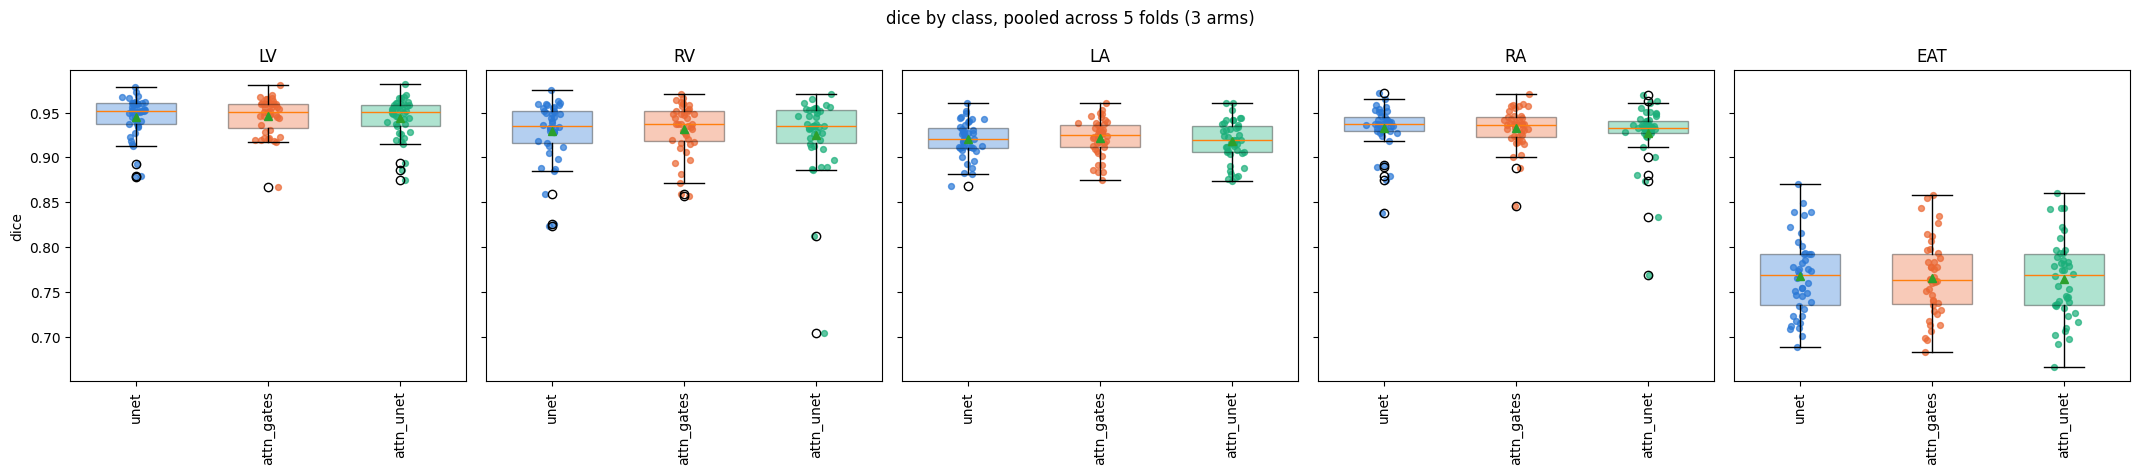

saved to checkpoints/both_attention_kfold_pooled/plots/boxplot_dice.png


In [10]:
ORDER_FIG = ['LV', 'RV', 'LA', 'RA', 'EAT']
METRIC = 'dice'   # 'dice' | 'precision' | 'recall' | 'hd95_mm' | 'assd_mm'

import matplotlib.pyplot as plt

arms_present = [a for a in ARMS if pooled_rows.get(a)]

if not arms_present:
    print('No arm has any finished folds yet -- nothing to plot.')
else:
  jitter = np.random.default_rng(0)
  fig, axes = plt.subplots(1, len(ORDER_FIG), figsize=(4.3 * len(ORDER_FIG), 4.8), sharey=True)
  axes = np.atleast_1d(axes)
  for ax, cls in zip(axes, ORDER_FIG):
    data = [[r[METRIC] for r in pooled_rows[a]
             if r['class_name'] == cls and np.isfinite(r[METRIC])]
            for a in arms_present]

    box = ax.boxplot(data, tick_labels=arms_present, showmeans=True, widths=0.6, patch_artist=True)
    for patch, a in zip(box['boxes'], arms_present):
        patch.set_facecolor(ARM_COLORS[a])
        patch.set_alpha(0.35)
    for i, (vals, a) in enumerate(zip(data, arms_present), start=1):
        ax.scatter(jitter.normal(i, 0.045, len(vals)), vals, color=ARM_COLORS[a], alpha=0.7, s=18)
    ax.set_title(cls)
    ax.tick_params(axis='x', rotation=90)
    ax.set_ylabel(METRIC if ax is axes[0] else '')
  fig.suptitle(f'{METRIC} by class, pooled across {K_FOLDS} folds ({len(arms_present)} arms)')
  fig.tight_layout()
  save_path = PLOTS_DIR / f'boxplot_{METRIC}.png'
  fig.savefig(save_path, dpi=150, bbox_inches='tight')
  plt.show()
  print(f'saved to {save_path}')

## Paired comparison, pooled across folds

`compare_runs` pairs on `(patient_id, class_name)` and runs paired Wilcoxon
signed-rank tests. Pairing is what makes this sensitive: both arms score the
same patients, and between-patient variance dominates everything else at this
sample size.

Note the sample size here is **42 patients**, not the 7 of a test-set
comparison -- pooling the five disjoint validation folds covers the whole
train+val pool. The `2/2**n` exact-Wilcoxon floor that makes per-chamber tests
hopeless at n=7 is not binding at n=42, so a per-chamber `p_holm` here is
meaningful rather than structurally impossible.

In [11]:
pooled_paths = {}
for arm in ARMS:
    path = POOLED_DIR / f'{arm}_val_metrics_per_patient.csv'
    metrics.write_csv(pooled_rows[arm], path)
    pooled_paths[arm] = path
print('pooled CSVs written to', POOLED_DIR)

baseline_patients = {r['patient_id'] for r in pooled_rows.get(BASELINE_ARM, [])}
if not baseline_patients:
    print(f'\n{BASELINE_ARM} has no finished folds yet -- nothing to compare against.')
else:
    for arm in ARMS:
        if arm == BASELINE_ARM:
            continue
        if not pooled_rows.get(arm):
            print(f'\n== {arm}: not run yet, skipping')
            continue

        arm_patients = {r['patient_id'] for r in pooled_rows[arm]}
        if arm_patients != baseline_patients:
            print(f'\nWARNING: {BASELINE_ARM} has {len(baseline_patients)} patients pooled, '
                  f'{arm} has {len(arm_patients)} -- compare_runs will only use the '
                  f'{len(baseline_patients & arm_patients)} patients shared by both.')

        print(f'\n===== {BASELINE_ARM}  vs  {arm}  (pooled train+val) =====')
        comparison = metrics.compare_runs(pooled_paths[BASELINE_ARM], pooled_paths[arm],
                                          label_a=BASELINE_ARM, label_b=arm)
        print(metrics.format_comparison(comparison, BASELINE_ARM, arm))

INFO: Wrote 210 rows to checkpoints/both_attention_kfold_pooled/unet_val_metrics_per_patient.csv


INFO: Wrote 210 rows to checkpoints/both_attention_kfold_pooled/attn_gates_val_metrics_per_patient.csv


INFO: Wrote 210 rows to checkpoints/both_attention_kfold_pooled/attn_unet_val_metrics_per_patient.csv


pooled CSVs written to checkpoints/both_attention_kfold_pooled

===== unet  vs  attn_gates  (pooled train+val) =====
class               metric      n        unet  attn_gates      diff         p    p_holm
---------------------------------------------------------------------------------------
 EAT                dice       42      0.7685      0.7628   -0.0039    0.1787    1.0000
 EAT                hd95_mm    42        4.58        4.52     +0.00    0.5563    1.0000
 EAT                assd_mm    42        1.27        1.25     +0.00    0.9113    1.0000
 LA                 dice       42      0.9209      0.9251   +0.0011    0.2743    1.0000
 LA                 hd95_mm    42        3.99        3.75     -0.12    0.3252    1.0000
 LA                 assd_mm    42        1.22        1.22     -0.02    0.0800    1.0000
 LV                 dice       42      0.9516      0.9504   -0.0000    0.9704    1.0000
 LV                 hd95_mm    42        3.75        3.74     +0.00    0.8505    1.0000
 LV

### Cross-fold consistency

The pooled p-value says whether an arm differs from the baseline; this says
whether it differs the *same way* on every fold. A consistent direction across
folds is what a real effect looks like. Signs that split roughly evenly are
the signature of no effect, and are worth more than the p-value alone when the
effect size is small.

attn_gates   beat unet in 3/5 folds   deltas: -0.0011 +0.0009 -0.0011 +0.0025 +0.0024   mean +0.0007
attn_unet    beat unet in 0/5 folds   deltas: -0.0016 -0.0018 -0.0039 -0.0068 -0.0028   mean -0.0034


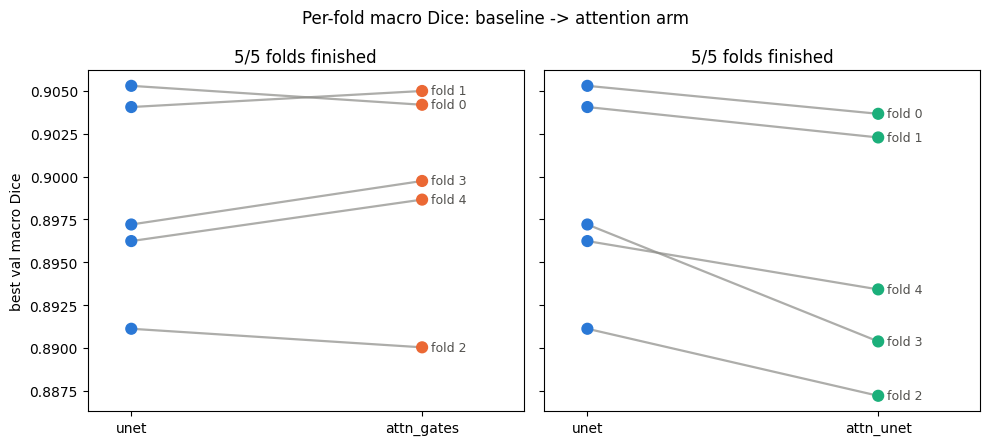

saved to checkpoints/both_attention_kfold_pooled/plots/cross_fold_consistency.png


In [12]:
fold_scores = {arm: [] for arm in ARMS}
for arm in ARMS:
    for f in range(K_FOLDS):
        cfg_path = run_dir_for(RUN_NAME_FN[arm](f)) / 'run_config.json'
        score = float('nan')
        if cfg_path.exists():
            cfg = json.loads(cfg_path.read_text())
            score = cfg.get('best_val_macro_dice', float('nan'))
        fold_scores[arm].append(score)

other_arms = [a for a in ARMS if a != BASELINE_ARM]
fig, axes = plt.subplots(1, len(other_arms), figsize=(5 * len(other_arms), 4.5), sharey=True)
axes = np.atleast_1d(axes)

any_plotted = False
for ax, arm in zip(axes, other_arms):
    folds_plotted = 0
    for f in range(K_FOLDS):
        b, a = fold_scores[BASELINE_ARM][f], fold_scores[arm][f]
        if not (np.isfinite(b) and np.isfinite(a)):
            continue
        ax.plot([0, 1], [b, a], color='#8a8a86', alpha=0.7, linewidth=1.6, zorder=1)
        ax.scatter([0, 1], [b, a], color=[ARM_COLORS[BASELINE_ARM], ARM_COLORS[arm]], s=60, zorder=2)
        ax.annotate(f'fold {f}', (1.03, a), va='center', fontsize=9, color='#52514e')
        folds_plotted += 1
    ax.set_xlim(-0.15, 1.35)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([BASELINE_ARM, arm])
    ax.set_title(f'{folds_plotted}/{K_FOLDS} folds finished')
    if folds_plotted:
        any_plotted = True
        deltas = [fold_scores[arm][f] - fold_scores[BASELINE_ARM][f] for f in range(K_FOLDS)
                  if np.isfinite(fold_scores[arm][f]) and np.isfinite(fold_scores[BASELINE_ARM][f])]
        n_up = sum(1 for d in deltas if d > 0)
        print(f'{arm:<12} beat {BASELINE_ARM} in {n_up}/{len(deltas)} folds   '
              f'deltas: ' + ' '.join(f'{d:+.4f}' for d in deltas)
              + f'   mean {np.mean(deltas):+.4f}')

axes[0].set_ylabel('best val macro Dice')
if any_plotted:
    fig.suptitle('Per-fold macro Dice: baseline -> attention arm')
    fig.tight_layout()
    save_path = PLOTS_DIR / 'cross_fold_consistency.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'saved to {save_path}')
else:
    print('No fold has finished on both an arm and the baseline yet -- nothing to plot.')

### Convergence check: was the shared 1e-5 fair to each arm?

Every arm trains at the same untuned LR (see the intro). That is only
defensible if the budget was not *binding* -- if each arm had converged well
before epoch 40 rather than being cut off mid-climb. Two readouts per fold:

- **`best_ep`** -- the epoch of the best validation macro Dice. Close to 40
  means the run was probably still improving when it ran out of budget.
- **`last10`** -- how much of the run's total gain arrived in the final 10
  epochs, as a percentage. Near 0% means a flat plateau.

An arm that looks starved here cannot be reported as "no benefit"; it would
need an LR probe first.

In [13]:
print(f'{"arm":<12}{"fold":>5}{"best":>10}{"final":>10}{"best_ep":>9}{"last10":>9}   {"duration":>10}')
import datetime as dt
for arm in ARMS:
    for f in range(K_FOLDS):
        cfg_path = run_dir_for(RUN_NAME_FN[arm](f)) / 'run_config.json'
        if not cfg_path.exists():
            continue
        cfg = json.loads(cfg_path.read_text())
        md_ = [e['val_macro_dice'] for e in (cfg.get('history') or [])
               if e.get('val_macro_dice') is not None]
        if not md_:
            continue
        best = max(md_)
        best_ep = md_.index(best) + 1
        gain_total = best - md_[0]
        last10 = 100 * (best - md_[max(0, len(md_) - 11)]) / gain_total if gain_total else float('nan')
        dur = ''
        if cfg.get('started') and cfg.get('finished'):
            dur = str(dt.datetime.fromisoformat(cfg['finished'])
                      - dt.datetime.fromisoformat(cfg['started']))
        flag = '  <-- still climbing?' if best_ep >= EPOCHS - 2 or last10 > 8 else ''
        print(f'{arm:<12}{f:>5}{best:>10.4f}{md_[-1]:>10.4f}{best_ep:>9}{last10:>8.1f}%   {dur:>10}{flag}')

arm          fold      best     final  best_ep   last10     duration
unet            0    0.9053    0.9047       34     2.3%      0:29:00
unet            1    0.9041    0.9032       32     1.8%      0:29:02
unet            2    0.8911    0.8892       29     1.9%      0:27:10
unet            3    0.8972    0.8929       25     3.2%      0:27:24
unet            4    0.8962    0.8947       17     0.1%      0:27:17
attn_gates      0    0.9042    0.9035       34     1.1%      1:28:28
attn_gates      1    0.9050    0.9040       29     2.3%      0:49:51
attn_gates      2    0.8900    0.8891       21     0.9%      0:50:58
attn_gates      3    0.8997    0.8968       32     1.0%      0:43:54
attn_gates      4    0.8987    0.8958       17     2.7%      0:40:13
attn_unet       0    0.9037    0.9031       30     0.0%      2:30:03
attn_unet       1    0.9023    0.9021       32     0.2%      1:56:47
attn_unet       2    0.8872    0.8847       29     0.4%      0:36:49
attn_unet       3    0.8904    0.8

### Precision / recall decomposition

Dice is the harmonic mean of the two, so it cannot separate over-segmentation
from under-segmentation. If attention gates were doing what they are supposed
to -- suppressing response outside the structure of interest -- the signature
would be a precision gain, most visibly on EAT, which is the diffuse,
low-Dice class where spurious response is most likely.

class          unet prec        unet rec attn_gates prec  attn_gates rec  attn_unet prec   attn_unet rec
LV                0.9481          0.9441          0.9478          0.9463          0.9399          0.9500
RV                0.9201          0.9406          0.9281          0.9373          0.9152          0.9390
LA                0.9222          0.9212          0.9200          0.9265          0.9201          0.9184
RA                0.9415          0.9264          0.9364          0.9309          0.9337          0.9241
EAT               0.7706          0.7730          0.7619          0.7772          0.7688          0.7664


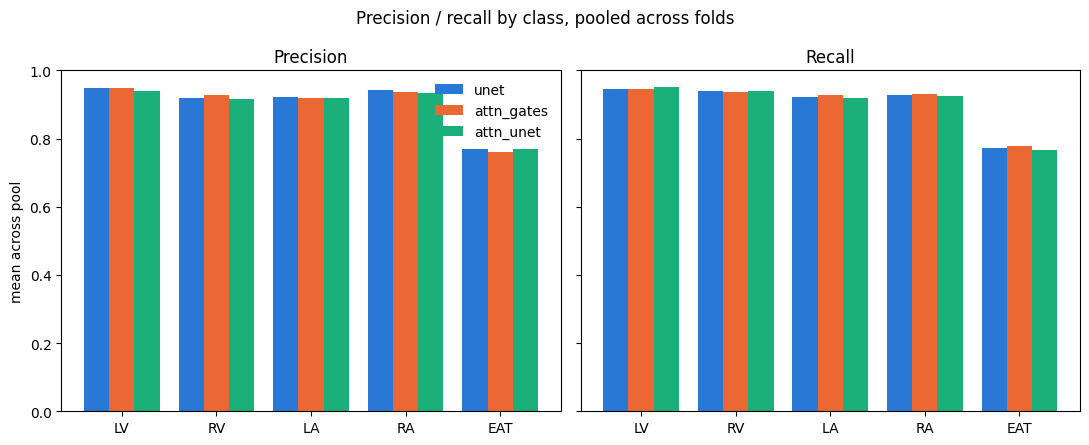

saved to checkpoints/both_attention_kfold_pooled/plots/precision_recall.png


In [14]:
print(f'{"class":<8}' + ''.join(f'{a + " prec":>16}{a + " rec":>16}' for a in ARMS))
for cls in ORDER_FIG:
    row_cells = []
    for a in ARMS:
        rows = [r for r in pooled_rows.get(a, []) if r['class_name'] == cls]
        p = np.nanmean([r['precision'] for r in rows]) if rows else float('nan')
        r_ = np.nanmean([r['recall'] for r in rows]) if rows else float('nan')
        row_cells.append(f'{p:>16.4f}{r_:>16.4f}')
    print(f'{cls:<8}' + ''.join(row_cells))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
x = np.arange(len(ORDER_FIG))
width = 0.8 / len(ARMS)
for ax, metric, title in zip(axes, ['precision', 'recall'], ['Precision', 'Recall']):
    for i, a in enumerate(ARMS):
        vals = []
        for cls in ORDER_FIG:
            rows = [r for r in pooled_rows.get(a, []) if r['class_name'] == cls]
            vals.append(np.nanmean([r[metric] for r in rows]) if rows else np.nan)
        offset = (i - (len(ARMS) - 1) / 2) * width
        ax.bar(x + offset, vals, width, label=a, color=ARM_COLORS[a])
    ax.set_xticks(x)
    ax.set_xticklabels(ORDER_FIG)
    ax.set_title(title)
    ax.set_ylim(0, 1)
axes[0].set_ylabel('mean across pool')
axes[0].legend(frameon=False)
fig.suptitle('Precision / recall by class, pooled across folds')
fig.tight_layout()
save_path = PLOTS_DIR / 'precision_recall.png'
fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'saved to {save_path}')

## Interpretation

Read the two arms together -- neither says this on its own.

**`attn_gates` is a clean null.** Macro Dice 0.8989 vs the baseline's 0.8985,
median paired difference **+0.0007, p = 0.74**; HD95 p = 0.89, ASSD p = 0.20;
no per-chamber test comes close (every `p_holm` = 1.0). Per-fold deltas split
in sign (-0.0011 / +0.0009 / -0.0011 / +0.0025 / +0.0024). At n=42 with
pairing, this is not an underpowered "no evidence of a difference" -- it is
evidence of no difference worth having. **Attention gates change nothing
measurable on this task.**

**`attn_unet` is reliably, negligibly worse.** Macro Dice 0.8948 vs 0.8985,
median paired difference **-0.0021, p = 0.0065**, negative on all five folds.
Statistically reliable and practically meaningless -- 0.2 Dice points.

**The gates leave no fingerprint at all.** The precision/recall decomposition
above is a check on mechanism rather than outcome: if the gates were
suppressing response outside each structure, precision should rise even if
Dice does not move. It does not. On EAT -- the diffuse, low-Dice class where
spurious response is most likely and the gates had the most to work with --
`attn_gates` is marginally *lower* on precision (0.7619 vs 0.7706) and
marginally higher on recall (0.7772 vs 0.7730), i.e. the opposite of the
predicted signature, at a magnitude indistinguishable from noise. So this is
not a case of the gates doing their job while Dice fails to reward it.

**Together they attribute that deficit.** The gates alone are neutral, so
MONAI's small but consistent loss comes from its *other* departures from this
project's UNet -- stride-2 conv downsampling instead of maxpool, and conv-based
skip fusion instead of concatenation into a `DoubleConv`. That is a sharper
conclusion than either arm supports alone, and it is the reason both are kept.

**What this licenses you to write.** "Attention gating gave no improvement over
the baseline UNet on this task at the project's training configuration, and
MONAI's full AttentionUnet was marginally worse." Not "attention gates do not
work" in general -- the LR was never tuned per architecture (intro), and this
is one dataset, one task, one budget. The convergence table above is what
keeps the LR caveat weak rather than fatal: if every arm plateaued well inside
40 epochs, no arm was starved, and a null is a null rather than a
truncation artifact.

**Why there is no winner to promote.** A null result means the baseline stands.
There is nothing here that justifies spending the held-out test set -- which is
why the cell below is gated shut and should stay that way for this experiment.

## Final: score a winner on the test set, once

Everything above pools validation-stage patients only; the test set has not
been touched.

**For this experiment there is no winner to score.** Neither attention arm
beat the baseline -- one was a null, the other marginally worse -- so the
baseline stands and the test set stays unspent. The cell is kept, gated shut,
for the same reason its siblings keep theirs: so the procedure is visible and
identical if a future arm does win.

k-fold gives `K_FOLDS` trained models per arm, not one. To stay comparable with
the sibling notebooks, this scores test with ONE fold's weights -- the fold
with the best validation macro Dice among the winning arm.

In [15]:
WINNING_ARM = BASELINE_ARM     # <- no attention arm won; baseline stands
RUN_FINAL_TEST = False         # <- flip to True deliberately, once, and only for a real winner

if RUN_FINAL_TEST:
    best_fold, best_score = None, -float('inf')
    for f in range(K_FOLDS):
        cfg_path = run_dir_for(RUN_NAME_FN[WINNING_ARM](f)) / 'run_config.json'
        cfg = json.loads(cfg_path.read_text())
        if cfg.get('best_val_macro_dice', -float('inf')) > best_score:
            best_fold, best_score = f, cfg['best_val_macro_dice']
    print(f'Scoring test with {WINNING_ARM} fold {best_fold} '
          f'(val macro Dice {best_score:.4f})')

    run_name = RUN_NAME_FN[WINNING_ARM](best_fold)
    run_dir = run_dir_for(run_name)
    _, _, test_idx = train.split_patients_kfold(
        dataset, fold=best_fold, k_folds=K_FOLDS, test_percent=TEST_PERCENT, seed=SPLIT_SEED
    )

    # build_model, not UNet(...) -- the winning arm may not be the plain UNet
    model = train.build_model(ARCH_FOR[WINNING_ARM], n_channels=N_CHANNELS,
                              n_classes=N_CLASSES, bilinear=False)
    model = model.to(memory_format=torch.channels_last).to(device=device)

    state_dict = torch.load(run_dir / 'best.pth', map_location=device)
    state_dict.pop('mask_values', None)      # injected by train.py, not a real weight
    model.load_state_dict(state_dict)
    model.eval()

    rows, summary = metrics.report(
        model, dataset, test_idx, device,
        n_classes=N_CLASSES,
        out_dir=run_dir, split_name='test',
        class_names=train.PHASE_CLASS_NAMES[PHASE],
        batch_size=BATCH_SIZE,
    )
    print(metrics.format_summary(summary))
else:
    print('RUN_FINAL_TEST is False -- and for this experiment it should stay False: '
          'no attention arm beat the baseline, so there is nothing to promote.')

RUN_FINAL_TEST is False -- and for this experiment it should stay False: no attention arm beat the baseline, so there is nothing to promote.
